<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Inferential_statistics_parametric_and_non_parametric_hypothesis_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to Statistics III: Inferential**
___

Previously, we learned that statistics is the study of collecting, analyzing, and interpreting data. Today, humans generate and collect more data than ever before. Every time we send a text message, make an online purchase, or post a photo on social media, we generate new data. As the amount of data increases, so does the need to analyze and interpret it. This is a key reason why statistics and data-driven work are so important. Therefore, the field of data analysis is growing almost as rapidly as data itself.

Data professionals use statistics to analyze data in business, medicine, science, engineering, government, and more. Data professionals use the power of statistical methods to identify meaningful patterns and find relationships in data, analyze and quantify uncertainty, generate insights from data, make accurate predictions about the future, and solve complex problems.

Even if we haven't studied statistics, we probably use statistics every day. For example, we start our day by checking the weather online, where we learn that there is a 70 percent chance of rain or a 50 percent chance of snow. Perhaps we visit a sports website to learn about our favorite baseball player's batting average or basketball player's scoring average. In a news app, we might find an election poll that reports a three percent margin of error and notes that an online survey was used to collect the data. Or perhaps we are a parent, and when we take our child for a routine checkup, we learn that their height and weight fall within certain percentiles. When we ask for more information, the doctor shows us the median height and weight for all children the same age. These scenarios involve statistical concepts that we will learn more about.


In [ ]:
# importing libraries

# data manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics
import statsmodels.api as sm
import scipy.stats as stats

# settings
import warnings
warnings.filterwarnings('ignore')

## **1. Inferential Statistics**

Descriptive statistics only describe the condition of the data presented to us. Meanwhile, the goal of inferential statistics is to make generalizations or conclusions for a population.

This generalization or conclusion is made using a sample drawn randomly from the population. The truth or reliability of the generalization is measured using probability.

Methods commonly used to make inferences include:
- Point estimation
- Interval estimation
- Hypothesis testing

### `Estimation`

In inferential statistics, sample data is used to form two types of parameter estimators:
- First, a `Point Estimate`, or estimate for a single number.
- Second, a `Confidence Interval`, or confidence interval.

**Point Estimate**

In a point estimate, an estimate is calculated from sample data and used as the best estimate for an unknown parameter. The sample used to make a single estimate is assumed to have been drawn randomly from the population.

Examples of symbols for single estimates are:
- To estimate μ (Population Mean), we can use the estimator x̄.
- To estimate P (Population Proportion), we can use the estimator p.

A good estimator is one with a sampling distribution centered around the parameter and the smallest standard error.

However, we cannot rely solely on a single estimate. This is because a single estimate is only an estimate and can be wrong or far from the true value. We also cannot know how close the estimate is to the parameter. We need to measure how close our estimate is and how far we are likely to be off.

Interval Estimate

Now that we understand single estimates, let's discuss interval estimates. Every estimate has a certain confidence level.

We create an interval that we expect to contain the parameter with a certain confidence level. The confidence level is a number from 0 to 1, representing the probability (often 0.90 (90%), 0.95 (95%), or 0.99 (99%).

A 95% confidence level means that if we take a sample size of n and repeat the process 20 times, we are confident that the parameter is covered by the confidence interval 19 times. This confidence level at the sample level can be generalized to the population level.

![Interval Estimate](https://image.slidesharecdn.com/lecture6pointandintervalestimation-230715194232-c98e07d2/85/lecture-6-point-and-interval-estimationpptx-21-320.jpg?cb=1689451102)

### `Confidence Interval`

**A Confidence Interval (CI)** is a type of estimate calculated from statistical observational data. A confidence interval proposes a range of plausible values for an unknown parameter (e.g., the mean). The interval has an associated level of confidence that the true parameter falls within the proposed range.

There are two examples of confidence intervals:
- Confidence intervals for proportions
- Confidence intervals for means.

**Confidence interval for proportion**

The confidence interval for a population proportion p, using the sample proportion p̂ and the standard error $se = \sqrt{\hat{p}(1 - \hat{p})/n}$ for a sample size n, is:

$$\hat{p} \pm z(se),\text{ ie } \hat{p} \pm z\sqrt{\hat{p}(1 - \hat{p})/n}$$

For 90%, 95%, and 99% confidence intervals, the z-value is 1.645, 1.96, and 2.58, respectively. This method assumes:
- The data were randomly sampled.
- The sample size is large enough so that the number of successes and failures, $n\hat{p}$ and $n(1 – \hat{p})$, are both at least 15 data points.

**Confidence Interval for the Mean**

The confidence interval for the mean proportion with a 95% confidence interval is:

$$\bar{x} \pm t_{.025}(se),\text{ where } se = s/\sqrt{n}$$

Where the degrees of freedom (df) = n-1 for the t-score $t_{.025}$ (total probability 0.05 at two tails). To use this method:
- Data are randomly sampled.
- The population distribution is approximately normal.

In [ ]:
# Loading dataset
train_csv_url = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/train.csv'
data = pd.read_csv(train_csv_url)
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# columns
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

We will try to build a confidence interval for the average with a 95% confidence interval.

In [ ]:
np.random.seed(10)

# take samples
sample_size = 1000
sample = np.random.choice(a=data['SalePrice'], size=sample_size)
sample_mean = sample.mean()

# significance level
alpha = 0.05

# degrees of freedom
df = sample_size

# get t-critical value
t_critical = stats.t.ppf(1 - alpha/2, df)

# get the population std deviation
pop_stdev = data['SalePrice'].std()

# standard error
standard_error = pop_stdev/ np.sqrt(sample_size)

# margin of error
margin_of_error = t_critical * standard_error

#confidence interval
confidence_interval = (sample_mean - margin_of_error,
sample_mean + margin_of_error )

# print results
print('t-critical value:', t_critical)
print('Population mean:', data['SalePrice'].mean())
print('Sample mean:', sample_mean)
print('Confidence Interval for Mean with 95% confidence level:', confidence_interval)

t-critical value: 1.9623390808264074
Population mean: 180921.19589041095
Sample mean: 182470.241
Confidence Interval for Mean with 95% confidence level: (np.float64(177540.46743680656), np.float64(187400.01456319346))


Notice that the population mean is contained within our interval. A 95% confidence interval means that if we took many samples and created confidence intervals for each sample, 95% of our sample confidence intervals would contain the true population mean.

Now, let's create some confidence intervals and plot them to get a better understanding of what it means to "capture" the population mean.

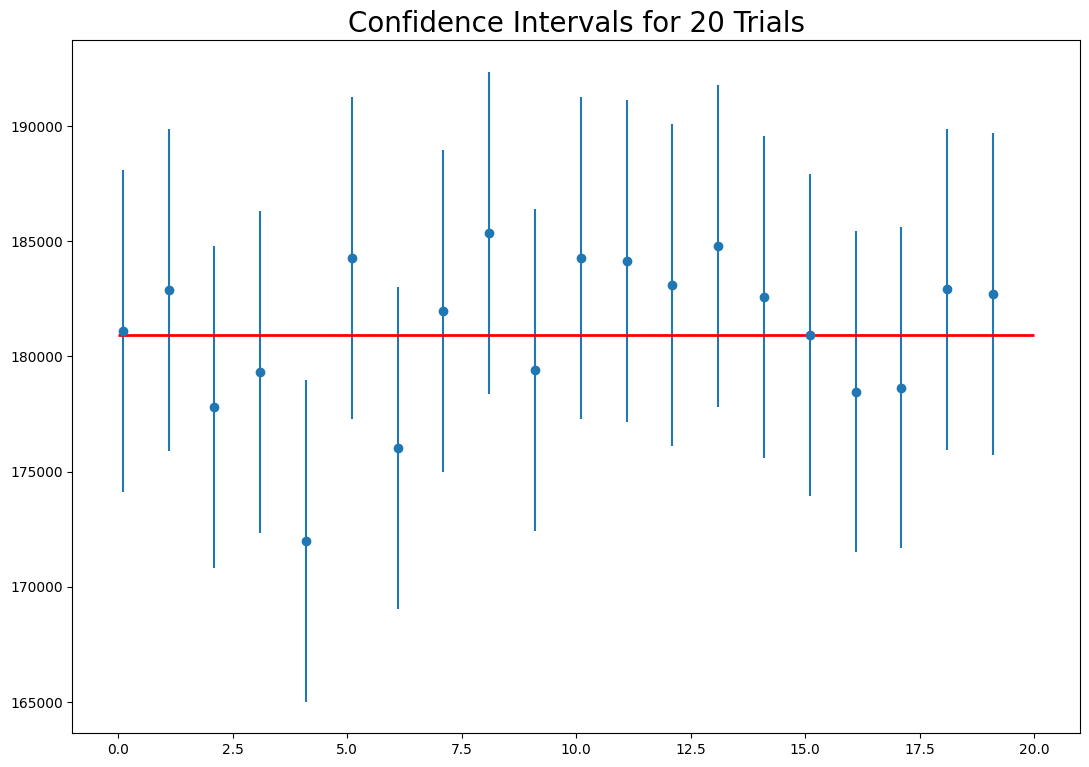

In [ ]:
np.random.seed(12)

sample_size = 500

intervals = []
sample_means = []

for sample in range(20):
    sample = np.random.choice(a= data['SalePrice'], size = sample_size)
    sample_mean = sample.mean()
    sample_means.append(sample_mean)

    # significance level
    alpha = 0.05

    # degree of freedom
    df = sample_size - 1

    # Get the t-critical value*
    t_critical = stats.t.ppf(1 - alpha/2, df)

    # Get the population standard deviation
    pop_stdev = data['SalePrice'].std()

    margin_of_error = t_critical * (pop_stdev/np.sqrt(sample_size))

    confidence_interval = (sample_mean - margin_of_error,
                           sample_mean + margin_of_error)

    intervals.append(confidence_interval)


plt.figure(figsize=(13, 9))

plt.errorbar(x=np.arange(0.1, 20, 1),
             y=sample_means,
             yerr=[np.abs((top-bot))/2 for top,bot in intervals],
             fmt='o')

plt.hlines(xmin=0, xmax=20,
           y=data['SalePrice'].mean(),
           linewidth=2.0,
           color="red")
plt.title('Confidence Intervals for 20 Trials', fontsize = 20)
plt.show()

It can be seen that of the 20 confidence intervals we created, 19 of them cover the mean of the population.

## **2. Hypothesis Testing**

A statistical hypothesis, sometimes called confirmatory data analysis, is a testable hypothesis based on observations of a process modeled through a set of random variables. Statistical hypothesis testing is a method of statistical inference.

The steps required to conduct a hypothesis test include:

1. State the null hypothesis and alternative hypothesis.
2. Choose a significance level.
3. Calculate the p-value.
4. Reject or fail to reject the null hypothesis.

### `Null Hypothesis`

In Inferential Statistics, **The null hypothesis is a general statement or default position that there is no relationship between two measured phenomena or no relationship between groups.**

Statistical hypothesis testing is based on a statement called the null hypothesis, which assumes nothing interesting occurs between any of the variables being tested.

### `Alternate Hypothesis`

An alternative hypothesis is an alternative to the null hypothesis. For example, if our null hypothesis is **Data is normally distributed**, then our alternative hypothesis is **Data is not normally distributed.** Essentially, we are looking to see if there is enough change (with the alternative hypothesis) to reject the null hypothesis.

The null hypothesis is always assumed to be true, and statistical evidence is needed to reject the null hypothesis in favor of the alternative hypothesis.

### `Significance level`

The significance level (usually denoted by the letter α) is the probability threshold that determines when we reject the null hypothesis. The significance level can also be defined as the probability of incorrectly rejecting the null hypothesis when it is actually true.

### `P-value`

The p-value refers to the probability of observing results that are the same or more extreme than those observed when the null hypothesis is true.

If the p-value is less than the significance level ($\alpha$), then we reject the null hypothesis and accept that the alternative hypothesis is true.

## **3. Hypothesis Testing for Mean**

This test is used to prove whether the estimated mean value in a population is correct or incorrect. There are several types of hypothesis tests for the mean, tailored to the data conditions.
- First, the T-test for testing the hypothesis of the mean of a single population.
- Second, the T-test for testing the hypothesis of the mean of two unrelated population samples, whether with equal or unequal variances.
- Third, the T-test for testing the hypothesis of the mean of two paired samples.
- Finally, the ANOVA F-test for testing the hypothesis of the mean of more than two populations.

In [ ]:
# Loading dataset
bestsellerswithcategories_csv_url = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/bestsellers%20with%20categories.csv'
df = pd.read_csv(bestsellerswithcategories_csv_url)
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


### `a. One Sample T-test`

This type of t-test is used to test an estimate or hypothesis about the mean in a single population. For example, we want to compare the mean of a group (Group A) with the expected mean.

In this case, we want to test whether the average price of books is $10.

First, we state the null hypothesis and the alternative hypothesis.

- `H0`: $\mu_\text{book price}$ = 10
- `H1`: $\mu_\text{book price}$ != 10

Then we choose the significance level.
- Significance level ($\alpha$) = 0.05

Next, we calculate the p-value.

In [ ]:
# One sample t-test
from scipy.stats import ttest_1samp

pop_mean = 10

stat, pvalue = ttest_1samp(a=df['Price'], popmean = pop_mean)
print(pvalue)

5.001628960126041e-11


Finally, we draw the following conclusion:

In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
We do NOT have enough evidence to say that the average price of books is NOT equal to $10.
''')
else:
  print(f'''
pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
We have enough evidence to say that the average price of books is NOT equal to $10.
''')


pvalue = 0.00000. pvalue <= 0.05. Reject Ho.
We have enough evidence to say that the average price of books is NOT equal to $10.



### `b. Two Sample t-test (unpaired)`

This hypothesis test is used to test the hypothesis or assumption of the average of two independent populations. Independence means that the two populations are not related to each other.

In this case, we want to compare the average book prices in two genre groups (Fiction and Non-Fiction).

First, we state the null hypothesis and the alternative hypothesis.

- `H0`: $\mu_\text{fiction book price}$ = $\mu_\text{non-fiction book price}$
- `H1`: $\mu_\text{fiction book price}$ != $\mu_\text{non-fiction book price}$

Then we select the significance level.
- Significance level ($\alpha$) = 0.05

Next, we calculate the p-value. However, before that, we will first check the variance of book prices across the two genres.

In [ ]:
# variance for fiction books
fiction_var = df[df['Genre']=='Fiction']['Price'].var()

# variance for non-fiction books
non_fiction_var = df[df['Genre']=='Non Fiction']['Price'].var()

ratio = non_fiction_var / fiction_var
ratio

1.9735421621702545

Because the variance ratio is 73.49 : 145.04 = 1 : 1.97, we assume that the population variance is equal (maximum 1:4)

In [ ]:
from scipy.stats import ttest_ind

stat, pvalue = ttest_ind(
    a = df[df['Genre']=='Fiction']['Price'], # price column for fiction books
    b = df[df['Genre']=='Non Fiction']['Price'], # price column for non-fiction books
    equal_var=True,
    alternative='two-sided' # two-tailed, using != in H1
)

print(pvalue)

1.612435071812073e-05


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
  We do NOT have enough evidence to say that the average price of fiction books is NOT the same as the average price of non-fiction books.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the average price of fiction books is NOT the same as the average price of non-fiction books.
''')


  pvalue = 0.00002. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that the average price of fiction books is NOT the same as the average price of non-fiction books.



In [ ]:
df.groupby('Genre')['Price'].mean()

,Price
Genre,
Fiction,10.850000
Non Fiction,14.841935


For example, in another case, we want to test the following hypothesis:

- `H0`: $\mu_\text{price of fiction books}$ = $\mu_\text{price of non-fiction books}$
- `H1`: $\mu_\text{price of fiction books}$ > $\mu_\text{price of non-fiction books}$

In [ ]:
from scipy.stats import ttest_ind

stat, pvalue = ttest_ind(
  a = df[df['Genre']=='Fiction']['Price'], # price column for fiction books
  b = df[df['Genre']=='Non Fiction']['Price'], # price column for non-fiction books
  equal_var=True,
  alternative='greater' # greater, using > in H1
)

print(pvalue)

0.9999919378246409


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
  We do NOT have enough evidence to say that the average price of fiction books is GREATER than the average price of non-fiction books.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the average price of fiction books is GREATER than the average price of non-fiction books.
''')


  pvalue = 0.99999. pvalue > 0.05. Fail To Reject Ho.
  We do NOT have enough evidence to say that the average price of fiction books is GREATER than the average price of non-fiction books.



Or in another case, we want to test the following hypothesis:

- `H0`: $\mu_\text{price of fiction books}$ = $\mu_\text{price of non-fiction books}$
- `H1`: $\mu_\text{price of fiction books}$ < $\mu_\text{price of non-fiction books}$

In [ ]:
from scipy.stats import ttest_ind

stat, pvalue = ttest_ind(
  a = df[df['Genre']=='Fiction']['Price'], # price column for fiction books
  b = df[df['Genre']=='Non Fiction']['Price'], # price column for non-fiction books
  equal_var=True,
  alternative='less' # less, using < in H1
)

print(pvalue)

8.062175359060365e-06


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
  We do NOT have enough evidence to say that the average price of fiction books is LESS than the average price of non-fiction books.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the average price of fiction books is LESS than the average price of non-fiction books.
''')


  pvalue = 0.00001. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that the average price of fiction books is LESS than the average price of non-fiction books.



### `c. Two Sample t-test (Paired)`

This hypothesis test is used to compare the means of two related groups (group A and group B). Groups A and B are the same subjects, but at different times.

In this case, we want to compare the average concentration power when not using a smartphone and when using a smartphone in the same individuals.

In [ ]:
using_Smartphone = [604,556,542,522,469,544,513,470,556,531,599,537,619,536,554,467]
no_Smartphone = [636,623,615,672,601,600,542,554,543,520,609,559,595,565,573,554]

# create dataframe
df_paired = pd.DataFrame({
    'No':no_Smartphone,
    'Yes':using_Smartphone
})

df_paired['diff'] = df_paired['No'] - df_paired['Yes']
df_paired.head()

,No,Yes,diff
0,636,604,32
1,623,556,67
2,615,542,73
3,672,522,150
4,601,469,132


Let's first state the null hypothesis and the alternative hypothesis.

- `H0`: $\mu_\text{score no smartphone}$ = $\mu_\text{score with smartphone}$
- `H1`: $\mu_\text{score no smartphone}$ > $\mu_\text{score with smartphone}$

In other words, the hypothesis can also be written like this:

- `H0`: $\mu_\text{score no smartphone}$ - $\mu_\text{score with smartphone}$ = 0
- `H1`: $\mu_\text{score no smartphone}$ - $\mu_\text{score with smartphone}$ > 0

In [ ]:
# Method 1: ttest 1 sample

stat, pvalue = ttest_1samp(a=df_paired['diff'], popmean=0, alternative='greater')
print(pvalue)

0.0010595522508415644


In [ ]:
# Method 2:
from scipy.stats import ttest_rel

stat, pvalue = ttest_rel(
a = df_paired['No'], # Score of group 'No'
b = df_paired['Yes'], # Score group 'Yes'
alternative='greater'
)

print(pvalue)

0.0010595522508415644


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
  We do NOT have enough evidence to say that the average concentration power when not using a smartphone is GREATER than the average concentration power when using a smartphone.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the average concentration power when not using a smartphone is GREATER than the average concentration power when using a smartphone.
''')


  pvalue = 0.00106. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that the average concentration power when not using a smartphone is GREATER than the average concentration power when using a smartphone.



### `d. One-Way ANOVA f-test (>2 sample means)`

The ANOVA F-Test is used to test the hypothesis of the average in more than two populations.

In this case, we have a dataset containing students' travel methods and school hours. We want to test whether there is a difference in the average study hours for each travel method.

In [ ]:
# create dummy dataset
transport = []
method = ['Walking ','Public ','Private ']

for i in method:
    transport.extend((i*10).split())

df_transport = pd.concat([
    pd.Series(transport, name='Transportation'),
    pd.Series([5,4,5,6,5,3,2,4,5,5,7,7,5,6,4,6,5,5,6,7,5,4,5,6,6,5,5,5,7,7], name='Study Hours')],
    axis=1)

df_transport

,Transportation,Study Hours
0,Walking,5
1,Walking,4
2,Walking,5
3,Walking,6
4,Walking,5
5,Walking,3
6,Walking,2
7,Walking,4
8,Walking,5
9,Walking,5


From the data above we can make a summary table as follows:

In [ ]:
df_transport.groupby('Transportation')[['Study Hours']].mean()

,Study Hours
Transportation,
Private,5.5
Public,5.8
Walking,4.4


We can also display visualizations in the form of bar plots.

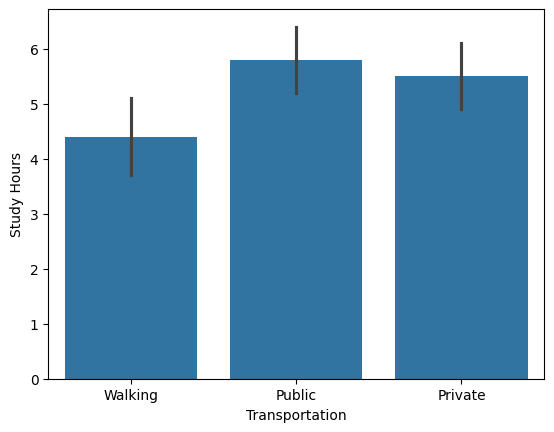

In [ ]:
sns.barplot(data=df_transport, x='Transportation', y='Study Hours')
plt.show()

Next, we will conduct a hypothesis test:

- `H0`: The average study hours for each group are the same.
- `H1`: There is at least one group whose study hours differ. But we don't know which one.

In [ ]:
# One-way ANOVA
from scipy.stats import f_oneway

stat, pvalue = f_oneway(
    df_transport[df_transport['Transportation']=='Walking']['Study Hours'],
    df_transport[df_transport['Transportation']=='Public']['Study Hours'],
    df_transport[df_transport['Transportation']=='Private']['Study Hours']
)

print(pvalue)

0.0163405142361861


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
  We do NOT have enough evidence to say that there is at least one group whose average study hours differ, but we don't know which one.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that there is at least one group whose average study hours differ, but we don't know which one.
''')


  pvalue = 0.01634. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that there is at least one group whose average study hours differ, but we don't know which one.



Next, we also want to test:

- `H0`: $\mu_\text{study hours private}$ = $\mu_\text{study hours public}$
- `H1`: $\mu_\text{study hours private}$ != $\mu_\text{study hours public}$

In [ ]:
from scipy.stats import ttest_ind

stat, pvalue = ttest_ind(
  a = df_transport[df_transport['Transportation']=='Private']['Study Hours'],
  b = df_transport[df_transport['Transportation']=='Public']['Study Hours'],
  equal_var=True,
  alternative='two-sided' # less, using != on H1
)

print(pvalue)

0.5120073137681896


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
  We do NOT have enough evidence to say that the average private study hours are NOT the same as the average public study hours.
  (The averages are NOT significantly different.)
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the average private study hours are NOT the same as the average public study hours.
  (The averages are significantly different.)
''')


  pvalue = 0.51201. pvalue > 0.05. Fail to reject Ho.
  We do NOT have enough evidence to say that the average private study hours are NOT the same as the average public study hours.
  (The averages are NOT significantly different.)



## **4. Hypothesis Testing for the Median**

The hypothesis testing we discussed earlier is classified as parametric statistics.
We use non-parametric statistics when:
- First, we don't have enough data (small sample size)
- Second, the data is not normally distributed.

### `a. Wilcoxon`

The Wilcoxon Test is similar to the Two-Paired T-test, but is a non-parametric statistical test. Two-paired samples are often used in experimental situations. As researchers, we want to test whether there are differences before and after a specific action, event, or condition.

In the case study below, we created a dummy dataset containing a performance comparison between employees who used and did not use smartphones while working. We compared whether there were any differences in performance between the two conditions.

In [ ]:
with_smartphone = [604,556,540,522,469,544,513,470,556,531,599,537,619,536,554,467]
without_smartphone = [636,623,615,672,601,600,542,554,543,520,609,559,595,565,573,554]

df_paired = pd.DataFrame({
    'no':without_smartphone,
    'yes':with_smartphone
})

df_paired.head()

,no,yes
0,636,604
1,623,556
2,615,540
3,672,522
4,601,469


The hypothesis:

- `H0`: $M_\text{yes}$ = $M_\text{no}$
- `H1`: $M_\text{yes}$ < $M_\text{no}$

Or it could be rewritten

- `H0`: $M_\text{yes}$ - $M_\text{no}$ = 0
- `H1`: $M_\text{yes}$ - $M_\text{no}$ < 0

In [ ]:
# calculate the difference between 'yes' and 'no'
df_paired['diff'] = df_paired['yes']-df_paired['no']
df_paired.head()

,no,yes,diff
0,636,604,-32
1,623,556,-67
2,615,540,-75
3,672,522,-150
4,601,469,-132


In [ ]:
from scipy.stats import wilcoxon

# method 1: using the 'diff' column
stat, pvalue = wilcoxon(df_paired['diff'], alternative='less')
print(pvalue)

0.001599741499196222


In [ ]:
# Method 2
stat, pvalue = wilcoxon(
    x = df_paired['yes'],
    y = df_paired['no'],
    alternative='less'
)
print(pvalue)

0.001599741499196222


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
  We do NOT have enough evidence to say that the median performance score of employees who use smartphones while working is
  SMALLER than the median performance score of employees who do not use smartphones while working.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the median performance score of employees who use smartphones while working is
  SMALLER than the median performance score of employees who do not use smartphones while working.
''')


  pvalue = 0.00160. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that the median performance score of employees who use smartphones while working is
  SMALLER than the median performance score of employees who do not use smartphones while working.



We can also use the Wilcoxon test for one sample, for example:

- `H0`: $M_\text{yes}$ = 580
- `H1`: $M_\text{yes}$ != 580

Alternative writing:

- `H0`: $M_\text{yes}$ - 580 = 0
- `H1`: $M_\text{yes}$ - 580 != 0

In [ ]:
stat, pvalue = wilcoxon(x=df_paired['diff']-580, alternative='two-sided')
print(pvalue)

0.00043680902321148305


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho.
  We do NOT have enough evidence to say that the median performance score of employees who use smartphones while working is NOT EQUAL to 580.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that the median performance score of employees who use smartphones while working is NOT EQUAL to 580.
''')


  pvalue = 0.00044. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that the median performance score of employees who use smartphones while working is NOT EQUAL to 580.



### `b. Mann-Whitney`

The Mann-Whitney Test is similar to the Two-Sample Independent T-Test, but in a non-parametric statistical version. The Mann-Whitney Test is used for two unpaired populations. In this case study, we want to test whether there is a difference in median performance scores between employees who read books and those who don't.

In [ ]:
training = pd.concat([
    pd.Series(
        data = ['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'No','Yes','Yes', 'No','Yes','Yes','No','Yes','No','Yes','No','No','No','Yes'],
        name = 'Read Book'),
    pd.Series(
        data = [70,85,80,45,80,70,90,70,55,80,75,60,70,85,80,85,55,75,65,70], name ='Score')],
    axis = 1)

training.head()

,Read Book,Score
0,Yes,70
1,No,85
2,Yes,80
3,Yes,45
4,No,80


The hypothesis:

- `H0`: $M_\text{yes}$ = $M_\text{no}$
- `H1`: $M_\text{yes}$ != $M_\text{no}$

In [ ]:
from scipy.stats import mannwhitneyu

stat, pvalue =mannwhitneyu(
x = training[training['Read Book']=='Yes']['Score'], # score for the yes group
y = training[training['Read Book']=='No']['Score'], # score for group no
alternative = 'two-sided'
)

print(pvalue)

0.3992232671178132


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
We do NOT have enough evidence to say that the median performance score of employees who read the book is NOT the same as the median performance score of employees who did not read the book.
''')
else:
  print(f'''
pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
We have enough evidence to say that the median performance score of employees who read the book is NOT the same as the median performance score of employees who did not read the book.
''')


pvalue = 0.39922. pvalue > 0.05. Fail to reject Ho.
We do NOT have enough evidence to say that the median performance score of employees who read the book is NOT the same as the median performance score of employees who did not read the book.



### `c. Kruskal Wallis`

The Kruskal Wallis Test is used to test comparisons between more than two independent samples in non-parametric statistics. In this case study, we want to compare the amount of monthly investment between employees. Employees are divided into three categories based on their transportation use: pedestrians, public transportation users, and private vehicle drivers. We test whether there is a difference in the amount of monthly investment between the three.

In [ ]:
transport = []
method = ['Walking ', 'Public ', 'Private ']
for i in method:
    transport.extend((i*10).split())

transportdf = pd.concat([pd.Series(transport, name = 'Transportation'),
                         pd.Series([5,4,5,6,5,3,2,4,5,5,7,7,5,6,4,6,5,5,6,7,5,4,5,6,6,5,5,5,7,7], name = 'Monthly Investment')], axis =1)

transportdf.head()

,Transportation,Monthly Investment
0,Walking,5
1,Walking,4
2,Walking,5
3,Walking,6
4,Walking,5


Hypothesis:

- `H0`: The median monthly investment for each group is the same
- `H1`: There is at least one group with a different median monthly investment. But we don't know which one.

In [ ]:
from scipy.stats import kruskal

stat, pvalue = kruskal(
    transportdf[transportdf['Transportation']=='Walking']['Monthly Investment'],
    transportdf[transportdf['Transportation']=='Public']['Monthly Investment'],
    transportdf[transportdf['Transportation']=='Private']['Monthly Investment']
)

print(pvalue)

0.029913168775421856


In [ ]:
alpha = 0.05

if pvalue > alpha:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail to reject Ho.
  We do NOT have enough evidence to say that at least one group has a different median monthly investment.
  But we don't know which one.
''')
else:
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho.
  We have enough evidence to say that at least one group has a different median monthly investment.
  But we don't know which one.
''')


  pvalue = 0.02991. pvalue <= 0.05. Reject Ho.
  We have enough evidence to say that at least one group has a different median monthly investment.
  But we don't know which one.



In [ ]:
transportdf.groupby('Transportation').median()

,Monthly Investment
Transportation,
Private,5.0
Public,6.0
Walking,5.0
